# Projektrapport – Optimering och investeringsanalys för hushållsbatteri med AI-styrning

Elmarknaden i Sverige är rena "vilda västern" och det utlovas mycket, men hur ser verkligheten ut bakom de siffror som presenteras? 

Min idé med projektet var att samla in data (IoT såväl som affärsdata), se hur det faktiska utfallet varit utan batteri och skapa en simulering för att se hur det kunde ha sett ut om ett hushållsbatteri kunde utjämna pristopparna. Därefter är planen att skapa en AI-modell för styrning av batteriet baserat på de 30 månader timvis data jag sammanställt, i kombination med ytterligare IoT-data från SMHIs sensorer via deras öppna API.

1. Insamling av data
De data jag ville åt fanns dels hos min elleverantör (Halmstad Energi och Miljö) och dels hos leverantören av solpanelerna. Affärsdata i form av såld och köpt el kunde ganska enkelt hämtas via elleverantörens webbgränssnitt. 

Det uppstod dock problem att extrahera timvis historisk data direkt från växelriktaren på grund av begränsningar i Solis Clouds användargränssnitt (låst till dygnsdata vid längre tidsspann). Jag fick därför hämta IoT-data "på djupet" i deras system via en API-nyckel och en egen kodning.

Till detta laddade jag även ned data om soltimmar från Nasa Power, en satellitbaserad tjänst som mäter solinstrålning timvis. Detta för att kunna verifiera min egen solproduktion och ha som stöd för en AI-modell.

Efter lite massering av mina olika CSV-filer för att bl.a. synka tidsstämplar hade jag till sist en komplett fil med data för de 30 månader jag valt som tidsperiod.

In [ ]:
import hmac
import hashlib
import base64
import json
import requests
import time
import os
import pandas as pd
from datetime import datetime, timezone, timedelta
from dotenv import load_dotenv

# Läs in miljövariabler från .env
load_dotenv()
API_ID     = os.getenv("API_ID_SOLIS")
API_SECRET = os.getenv("API_SECRET_SOLIS")

INVERTER_SN = "1805040227120162"
BASE_URL    = "https://www.soliscloud.com:13333"

In [ ]:
def get_solis_headers(path: str, body_dict: dict) -> tuple[dict, str]:
    """Skapar HMAC-SHA1-signerade headers för Solis Cloud API."""
    body_str    = json.dumps(body_dict, separators=(",", ":"))
    md5_hash    = hashlib.md5(body_str.encode("utf-8")).digest()
    content_md5 = base64.b64encode(md5_hash).decode("utf-8")

    now      = datetime.now(timezone.utc)
    date_str = now.strftime("%a, %d %b %Y %H:%M:%S GMT")

    content_type = "application/json;charset=UTF-8"
    sign_ctype   = "application/json"          # Solis signerar utan charset
    sign_str     = "\n".join(["POST", content_md5, sign_ctype, date_str, path])

    hashed = hmac.new(API_SECRET.encode("utf-8"),
                      sign_str.encode("utf-8"),
                      hashlib.sha1).digest()
    sign   = base64.b64encode(hashed).decode("utf-8")

    headers = {
        "Content-MD5":   content_md5,
        "Content-Type":  content_type,
        "Date":          date_str,
        "Authorization": f"API {API_ID}:{sign}",
    }
    return headers, body_str


def fetch_day(target_date: str, tz_offset: int) -> pd.DataFrame | None:
    """
    Hämtar 5-minutersdata för ett dygn från Solis Cloud API.

    Args:
        target_date: Datum som sträng, t.ex. '2025-07-01'
        tz_offset:   UTC-offset (2 = CEST sommartid, 1 = CET vintertid)

    Returns:
        DataFrame med rådata, eller None om anropet misslyckas.
    """
    path    = "/v1/api/inverterDay"
    payload = {
        "sn":       INVERTER_SN,
        "money":    "EUR",
        "time":     target_date,
        "timeZone": tz_offset,
    }
    headers, body = get_solis_headers(path, payload)
    try:
        res  = requests.post(BASE_URL + path, headers=headers, data=body, timeout=15)
        data = res.json()
        if str(data.get("code")) == "0" and data.get("data"):
            return pd.DataFrame(data["data"])
    except Exception as e:
        print(f"  Fel vid {target_date}: {e}")
    return None

In [ ]:
def fetch_solis_year(target_year: int) -> pd.DataFrame | None:
    """
    Hämtar all tillgänglig data för ett kalenderår och sparar
    timvisa medelvärden (kW) till CSV.

    Args:
        target_year: Årtalet som ska hämtas, t.ex. 2024

    Returns:
        DataFrame med timvisa medelvärden, eller None.
    """
    start_date = datetime(target_year, 1, 1)
    end_date   = min(datetime(target_year, 12, 31),
                     datetime.now() - timedelta(days=1))

    # Datumgränser för sommartid i Sverige (ungefärliga)
    dst_start = datetime(target_year,  3, 25)
    dst_end   = datetime(target_year, 10, 25)

    all_days     = []
    current_date = start_date

    print(f"--- Hämtar data för {target_year} ({start_date.date()} → {end_date.date()}) ---")

    while current_date <= end_date:
        date_str  = current_date.strftime("%Y-%m-%d")
        tz_offset = 2 if dst_start <= current_date < dst_end else 1

        df_day = fetch_day(date_str, tz_offset)
        if df_day is not None:
            all_days.append(df_day)
            print(f"  {date_str} ✓ ({len(df_day)} punkter)", end="\r")

        current_date += timedelta(days=1)
        time.sleep(0.3)   # Respektera API:ets rate-limit

    if not all_days:
        print(f"Ingen data hittades för {target_year}.")
        return None

    full_df = pd.concat(all_days, ignore_index=True)

    # Konvertera timestamp (ms UTC) → svensk lokal tid
    full_df["timestamp"] = (
        pd.to_datetime(full_df["dataTimestamp"].astype(float), unit="ms", utc=True)
        .dt.tz_convert("Europe/Stockholm")
        .dt.tz_localize(None)
    )
    full_df["pac"] = pd.to_numeric(full_df["pac"], errors="coerce")
    full_df.set_index("timestamp", inplace=True)

    # Aggregera till timvisa medelvärden (kW)
    hourly_df = full_df["pac"].resample("1h").mean().reset_index()
    hourly_df.columns = ["timestamp", "avg_power_kw"]

    filename = f"solisdata_{target_year}_local.csv"
    hourly_df.to_csv(filename, index=False)
    print(f"\n✅ {target_year}: {len(all_days)} dagar → sparad som '{filename}'")
    return hourly_df


# --- Kör för önskade år ---
df_2023 = fetch_solis_year(2023)
df_2024 = fetch_solis_year(2024)
df_2025 = fetch_solis_year(2025)

In [ ]:
import pandas as pd
from io import StringIO
import numpy as np
from datetime import datetime

# ── 1. INLÄSNINGSFUNKTIONER ───────────────────────────────────────────────────

def load_el_data(filenames):
    """Läser el-filer från leverantör (semikolon-separerade, komma-decimal)."""
    dfs = []
    for f in filenames:
        print(f"Bearbetar el-leverantörsdata: {f}")
        df = pd.read_csv(f, sep=";", decimal=",", encoding="utf-8")
        df["timestamp"] = pd.to_datetime(df["Datum"])
        df = df.rename(columns={
            "El kWh":        "grid_import_kwh",
            "Produktion":    "grid_export_kwh",
            "Totalt re/kWh": "price_total_ore",
        })
        dfs.append(df[["timestamp", "grid_import_kwh", "grid_export_kwh", "price_total_ore"]])
    return pd.concat(dfs).drop_duplicates("timestamp")


def load_solis_data(filenames):
    """Läser Solis-inverterdata och konverterar W → kWh (timvärden)."""
    dfs = []
    for f in filenames:
        print(f"Bearbetar Solis-data: {f}")
        df = pd.read_csv(f)
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        # avg_power_kw är medel-kW per timme → kWh per timme
        df["total_production_kwh"] = pd.to_numeric(df["avg_power_kw"], errors="coerce") / 1000.0
        dfs.append(df[["timestamp", "total_production_kwh"]])
    return pd.concat(dfs).drop_duplicates("timestamp")


def load_nasa_data(filename):
    """Läser NASA POWER-data och justerar från fast UTC+1 till svensk lokaltid."""
    print(f"Bearbetar NASA-väderdata: {filename}")
    with open(filename, "r") as f:
        lines = f.readlines()
    start_idx = next(i for i, line in enumerate(lines) if line.startswith("YEAR"))
    df = pd.read_csv(StringIO("".join(lines[start_idx:])))
    df["timestamp"] = pd.to_datetime(
        df[["YEAR", "MO", "DY", "HR"]].rename(
            columns={"YEAR": "year", "MO": "month", "DY": "day", "HR": "hour"}
        )
    )
    # NASA LST = fast UTC+1; konvertera till Europe/Stockholm för sommar/vintertid
    df["timestamp"] = (
        df["timestamp"]
        .dt.tz_localize("Etc/GMT-1")
        .dt.tz_convert("Europe/Stockholm")
        .dt.tz_localize(None)
    )
    df = df.rename(columns={"ALLSKY_SFC_SW_DWN": "irradiance_wm2"})
    return df[["timestamp", "irradiance_wm2"]]


# ── 2. LADDA DATA ────────────────────────────────────────────────────────────

el_files = [
    "El - Erlandsliden 15 B, Halmstad 2023 - halvår.csv",
    "El - Erlandsliden 15 B, Halmstad 2024.csv",
    "El - Erlandsliden 15 B, Halmstad 2025.csv",
]
solis_files = [
    "solisdata_2023_local.csv",
    "solisdata_2024_local.csv",
    "solisdata_2025_local.csv",
]
nasa_file = "POWERPointHourly_20230701_20260323_056d66N_012d81E_LST.csv"

df_grid   = load_el_data(el_files)
df_inv    = load_solis_data(solis_files)
df_weather = load_nasa_data(nasa_file)

# ── 3. MERGE TILL MASTER ─────────────────────────────────────────────────────

master_df = (
    df_grid
    .merge(df_inv,     on="timestamp", how="left")
    .merge(df_weather, on="timestamp", how="left")
)

# Fyll nattimmarnas saknade produktion med 0
master_df["total_production_kwh"] = master_df["total_production_kwh"].fillna(0)

# ── 4. BERÄKNA ENERGIFLÖDEN ──────────────────────────────────────────────────

# A. Egenförbrukning = Produktion − Export (vad som aldrig lämnade huset)
master_df["self_consumption_kwh"] = (
    master_df["total_production_kwh"] - master_df["grid_export_kwh"]
).clip(lower=0)

# B. Total huslast = Köpt el + Egenförbrukning
master_df["total_house_load_kwh"] = (
    master_df["grid_import_kwh"] + master_df["self_consumption_kwh"]
)

# C. Nettobalans (+ = överskott, − = underskott)
master_df["net_balance_kwh"] = (
    master_df["total_production_kwh"] - master_df["total_house_load_kwh"]
)

# ── 5. FEATURE ENGINEERING ───────────────────────────────────────────────────

master_df["hour"]      = master_df["timestamp"].dt.hour
master_df["weekday"]   = master_df["timestamp"].dt.weekday
master_df["is_weekend"] = (master_df["weekday"] >= 5).astype(int)
master_df["month"]     = master_df["timestamp"].dt.month
master_df["season"]    = master_df["month"].map({
    12: "winter", 1: "winter", 2: "winter",
     3: "spring", 4: "spring", 5: "spring",
     6: "summer", 7: "summer", 8: "summer",
     9: "autumn", 10: "autumn", 11: "autumn",
})
master_df["hour_sin"] = np.sin(2 * np.pi * master_df["hour"] / 24)
master_df["hour_cos"] = np.cos(2 * np.pi * master_df["hour"] / 24)

# ── 6. TVÄTTA OCH SPARA ──────────────────────────────────────────────────────

# Rensa negativa energivärden och saknade priser
energy_cols = ["grid_import_kwh", "grid_export_kwh", "total_production_kwh",
               "self_consumption_kwh", "total_house_load_kwh"]
master_df[energy_cols] = master_df[energy_cols].clip(lower=0)
master_df["irradiance_wm2"] = master_df["irradiance_wm2"].replace(-999, np.nan).clip(lower=0)
master_df["price_total_ore"] = master_df["price_total_ore"].fillna(0)

master_df = master_df.sort_values("timestamp").reset_index(drop=True)
master_df.to_csv("master_energy_data.csv", index=False)

print(f"✅ master_energy_data.csv skapad – {len(master_df)} rader, {len(master_df.columns)} kolumner")
print(f"Datumintervall: {master_df['timestamp'].min()} → {master_df['timestamp'].max()}")
corr = master_df["total_production_kwh"].corr(master_df["irradiance_wm2"])
print(f"Synk-kontroll – korrelation Sol/Irradians: {corr:.2f}")
display(master_df.head())

Visualisering av energiprofilen 07-23 till 12-25.

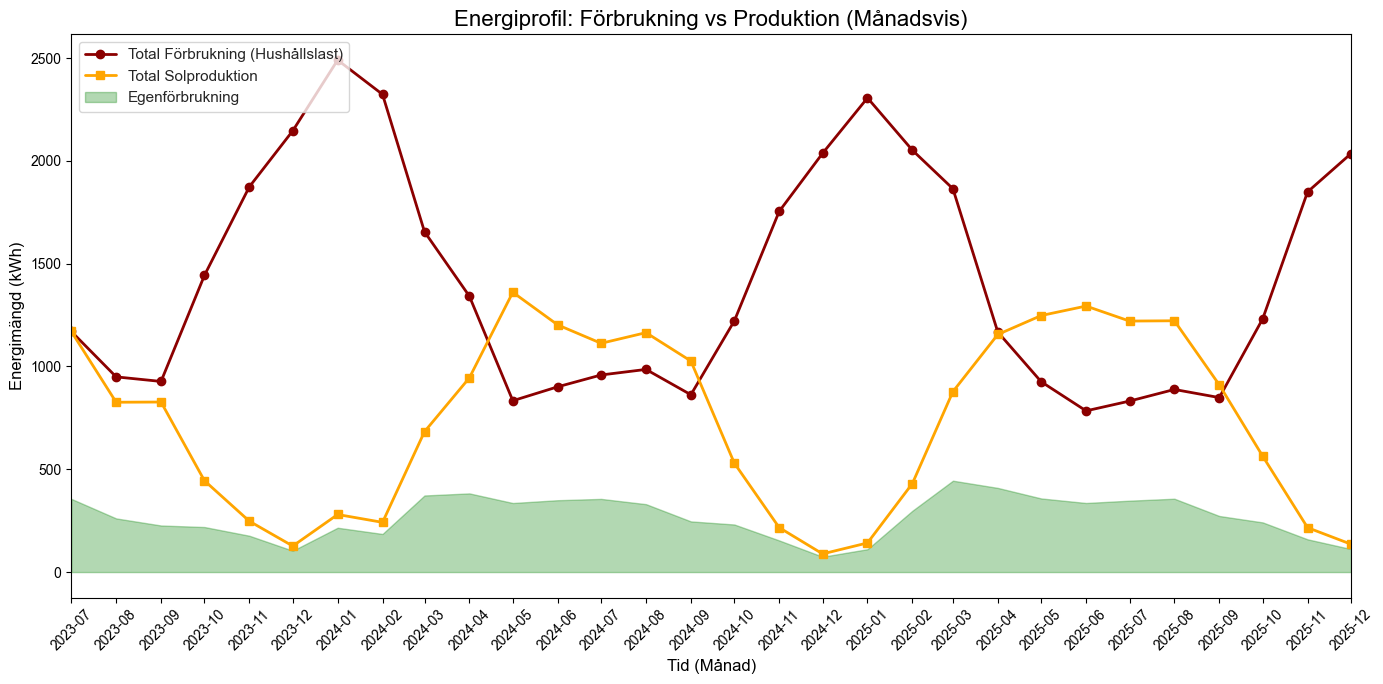

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 1. Ladda in data
path = r"Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
df = pd.read_csv(path, parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

# 2. Aggregera data per månad
monthly_data = df.resample('MS').agg({
    'grid_import_kwh': 'sum',
    'grid_export_kwh': 'sum',
    'total_production_kwh': 'sum',
    'total_house_load_kwh': 'sum',
    'self_consumption_kwh': 'sum'
})

# 3. Visualisering
fig, ax = plt.subplots(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Förbrukning och produktion
ax.plot(monthly_data.index, monthly_data['total_house_load_kwh'], 
         label='Total Förbrukning (Hushållslast)', marker='o', linewidth=2, color='darkred')
ax.plot(monthly_data.index, monthly_data['total_production_kwh'], 
         label='Total Solproduktion', marker='s', linewidth=2, color='orange')

# Egenförbrukning
ax.fill_between(monthly_data.index, monthly_data['self_consumption_kwh'], 
                 alpha=0.3, label='Egenförbrukning', color='green')

ax.set_xlim(monthly_data.index.min(), monthly_data.index.max())

# Snygga till
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

# -----------------------------------------------------------------

plt.title('Energiprofil: Förbrukning vs Produktion (Månadsvis)', fontsize=16)
plt.xlabel('Tid (Månad)', fontsize=12)
plt.ylabel('Energimängd (kWh)', fontsize=12)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


2. Beslutsstöd för investering i hushållsbatteri
Eftersom det har talats mycket om att komplettera solpaneler med batteri för att lagra oanvänd el och sedan använda den när solen gått ned i stället för att köpa el så gör jag en simulering. 

Det här visar hur det *kunde ha sett ut* om jag redan haft ett batteri med en smart styrning. 


In [8]:
import pandas as pd
import numpy as np

# 1. PARAMETRAR 
PATH        = r"Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
MOMS        = 1.25
TAX_FEES_KR = 0.7075  # 70,75 öre (Energiskatt + Nätavgift + Elhandel rörlig inkl moms)
SELL_ADJUST = 0.029   # 2,9 öre (Nätnytta – balanskostnad)
CAPACITY    = 18.0
EFFICIENCY  = 0.9
COST_18KWH  = 83939

# 2. LADDA DATA
df = pd.read_csv(PATH, parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

# 3. SMART SIMULERING (24h Rullande Lookahead)
def simulate_smart_lookahead(df_input, cap, eff=0.9):
    soc = 0.0
    total_profit = 0.0
    
    # Förberedelse: Hitta alla timmar där solproduktion > förbrukning
    solar_potential = df_input['total_production_kwh'] > df_input['total_house_load_kwh']
    
    # Loopa igenom varje timme
    for i in range(len(df_input)):
        current_ts = df_input.index[i]
        row = df_input.iloc[i]
        
        # Spotpris och marginaler för denna timme
        spot = row['price_total_ore'] / 100
        buy_p = spot * MOMS + TAX_FEES_KR
        sell_p = spot + SELL_ADJUST
        
        # Titta framåt: När börjar solen skina nästa gång?
        # Vi tittar 24h framåt
        future_24h = solar_potential.iloc[i : i+24]
        if future_24h.any():
            next_solar_ts = future_24h[future_24h].index[0]
            hours_to_solar = (next_solar_ts - current_ts).total_seconds() / 3600
        else:
            hours_to_solar = 24
            
        # --- LADDNING (SOL) ---
        if row['grid_export_kwh'] > 0:
            charge = min(row['grid_export_kwh'], (cap - soc) / eff)
            soc += charge * eff
            total_profit -= charge * sell_p # Förlorad säljintäkt
            
        # --- SMART URLADDNING ---
        elif row['grid_import_kwh'] > 0 and soc > 0:
            # Hitta maxpriset mellan NU och nästa soltillfälle
            window_to_solar = df_input.iloc[i : i + int(hours_to_solar) + 1]
            max_price_in_window = (window_to_solar['price_total_ore'] / 100).max()
            
            # Beslutslogik:
            # 1. Är det dyraste timmen innan nästa laddning? (Optimera vinst)
            is_peak = spot >= max_price_in_window
            
            # 2. Måste vi börja tömma för att hinna bli tomma till solen kommer? (Säkra plats)
            # Vi antar att huset kan svälja ca 1.5 kWh per timme
            needs_to_empty = soc > (hours_to_solar * 1.5)
            
            if is_peak or needs_to_empty:
                discharge = min(row['grid_import_kwh'], soc)
                soc -= discharge
                total_profit += discharge * buy_p # Sparad utgift
                
    return total_profit

# 4. KÖR OCH PRESENTERA
vinst_18 = simulate_smart_lookahead(df, CAPACITY)
total_years = (df.index.max() - df.index.min()).days / 365.25
annual_vinst = vinst_18 / total_years

print(f"--- Batterisimulering med 24h rolling lookahead) ---")
print(f"Analyserad period: {total_years:.1f} år")
print(f"Årlig Nettovinst (18kWh): {annual_vinst:,.0f} kr")
print(f"Återbetalningstid: {COST_18KWH/annual_vinst:.1f} år")

--- Batterisimulering med 24h rolling lookahead) ---
Analyserad period: 2.5 år
Årlig Nettovinst (18kWh): 2,625 kr
Återbetalningstid: 32.0 år


Ett sätt att spara pengar handlar om att att flytta konsumtion till soltimmar under sommaren och de billigaste timmarna nattetid under vintern. Vad kan det ge?

In [3]:
# --- LOAD SHIFTING ---
def simulate_smart_shifting_precise(df_input, shift_limit_daily=10.0):
    df_c = df_input.copy()
    df_c['date'] = df_c.index.date
    
    # Kolumner med faktiska priser från dataunderlaget
    df_c['buy_p'] = (df_c['price_total_ore'] / 100) * 1.25 + 0.7075
    df_c['sell_p'] = (df_c['price_total_ore'] / 100) + 0.029
    
    total_benefit = 0
    
    for date, day_data in df_c.groupby('date'):
        # 1. Hitta timmar att flytta FRÅN (Högst köppris)
        can_reduce = day_data[day_data['grid_import_kwh'] > 0].sort_values('buy_p', ascending=False)
        # 2. Hitta timmar att flytta TILL (Mest solöverskott/lägst säljpris)
        can_increase = day_data[day_data['grid_export_kwh'] > 0].sort_values('sell_p', ascending=True)
        
        # Beräkna hur mycket som faktiskt går att flytta
        to_shift = min(shift_limit_daily, day_data['grid_import_kwh'].sum(), day_data['grid_export_kwh'].sum())
        
        # Beräkna vinsten baserat på skillnaden i timpriserna
        current_shift = to_shift
        avoided_cost = 0
        for idx, row in can_reduce.iterrows():
            take = min(current_shift, row['grid_import_kwh'])
            avoided_cost += take * row['buy_p']
            current_shift -= take
            if current_shift <= 0: break
            
        current_shift = to_shift
        new_cost = 0
        for idx, row in can_increase.iterrows():
            use = min(current_shift, row['grid_export_kwh'])
            new_cost += use * row['sell_p']
            current_shift -= use
            if current_shift <= 0: break
            
        total_benefit += (avoided_cost - new_cost)
        
    return total_benefit

# Beräkna besparingen
vinst_styrning = simulate_smart_shifting_precise(df) / total_years
print(f"Årlig besparing med smart styrning av laster: {vinst_styrning:,.0f} kr")

Årlig besparing med smart styrning av laster: 3,052 kr


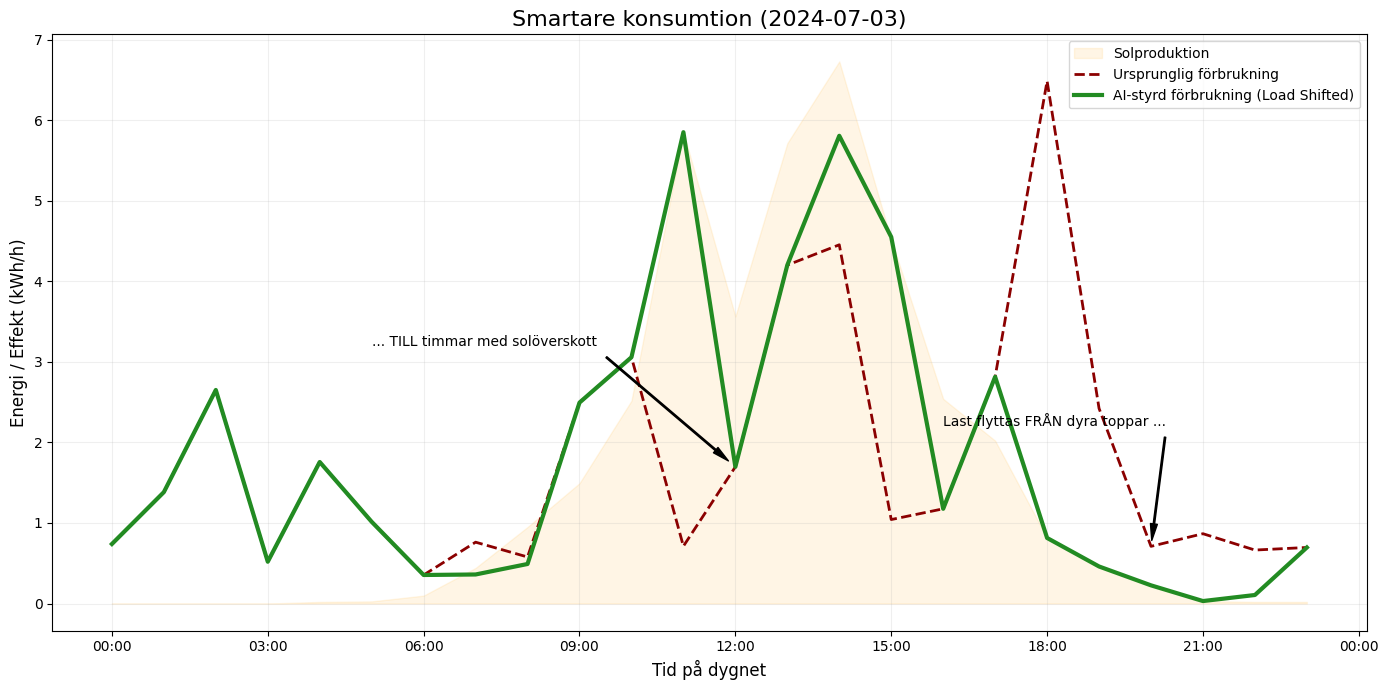

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. INSTÄLLNINGAR
# Ta en solig dag med både import (morgon/kväll) och export (mitt på dagen)
SAMPLE_DAY = '2024-07-03' 
SHIFT_LIMIT = 10.0 # kWh som AI:n tillåts flytta per dygn

# 2. FÖRBERED DATA FÖR EN SPECIFIK DAG
day_data = df.loc[SAMPLE_DAY].copy()

# Beräkna köppris för att identifiera toppar
day_data['buy_p'] = (day_data['price_total_ore'] / 100) * MOMS + TAX_FEES_KR

# Skapa kurvorna
original_load = day_data['total_house_load_kwh'].copy()
smart_load = original_load.copy()

# 3. AI-LOGIK: FLYTTA LASTEN (LOAD SHIFTING)
# Hitta timmar att flytta FRÅN (högst pris vid faktisk import)
can_reduce = day_data[day_data['grid_import_kwh'] > 0].sort_values('buy_p', ascending=False)
# Hitta timmar att flytta TILL (timmar med solöverskott)
can_increase = day_data[day_data['grid_export_kwh'] > 0].sort_values('grid_export_kwh', ascending=False)

# Beräkna hur mycket som kan flyttas för den aktuella dagen
to_shift = min(SHIFT_LIMIT, day_data['grid_import_kwh'].sum(), day_data['grid_export_kwh'].sum())

# Genomför flytten i datan
current_shift = to_shift
for idx, row in can_reduce.iterrows():
    take = min(current_shift, row['grid_import_kwh'])
    smart_load.loc[idx] -= take
    current_shift -= take
    if current_shift <= 0: break

current_shift = to_shift
for idx, row in can_increase.iterrows():
    use = min(current_shift, row['grid_export_kwh'])
    smart_load.loc[idx] += use
    current_shift -= use
    if current_shift <= 0: break

# 4. VISUALISERING
plt.figure(figsize=(14, 7))

# Solproduktionen som bakgrundsyta (kontext)
plt.fill_between(day_data.index, day_data['total_production_kwh'], 
                 color='orange', alpha=0.1, label='Solproduktion')

# Ursprunglig förbrukning
plt.plot(day_data.index, original_load, color='darkred', linewidth=2, 
         linestyle='--', label='Ursprunglig förbrukning')

# "Smart" AI-styrd förbrukning
plt.plot(day_data.index, smart_load, color='forestgreen', linewidth=3, 
         label='AI-styrd förbrukning (Load Shifted)')

# Formatering
plt.title(f'Smartare konsumtion ({SAMPLE_DAY})', fontsize=16)
plt.ylabel('Energi / Effekt (kWh/h)', fontsize=12)
plt.xlabel('Tid på dygnet', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right', frameon=True)

# Lite förklaringar
plt.annotate('Last flyttas FRÅN dyra toppar ...', 
             xy=(day_data.index[20], original_load.iloc[20]), 
             xytext=(day_data.index[16], original_load.iloc[20]+1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.annotate('... TILL timmar med solöverskott', 
             xy=(day_data.index[12], smart_load.iloc[12]), 
             xytext=(day_data.index[5], smart_load.iloc[12]+1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

Det här visar tydligt att ju 'smartare' man agerar genom Load Shifting, desto svårare blir det att räkna hem investeringen i ett batteri. Load Shifting har ju 100 % verkningsgrad och noll investeringskostnad, vilket 'stjäl' de mest lönsamma timmarna från batteriet. Ett batteri gör störst nytta med en 'dum' konsumtionskurva.

# AI-delen av projektet
För att uppfylla kunskapskraven kommer här ett AI-projekt baserat på mina data. Jag upptäckte under arbetet med denna modell att SMHI har ett utmärkt öppet API och kompletterar mina data för bättre resultat samt bygger även in deras STRÅNG-data om solinstrålningsprognos. 

## Verklig användning, utmaningar & möjligheter

Detta är den del Terese bad om i slutet av koden:



Affärsmässig möjlighet: Att aggregera tusentals sådana här batterier i en "Virtual Power Plant" (VPP) för att sälja stödtjänster (det är här de 18 % i avkastning faktiskt finns).



Etiska perspektiv: Materialval i batterier (litium/kobolt) kontra den miljönytta de gör genom att stabilisera elnätet.



Utmaningar: Datakvalitet från API:er, förändrade nätavgifter (effekttariffer) och politiska beslut som slopad skattereduktion.



Datadrivet: Du har inte bara "byggt något", du har analyserat något och kommit fram till en slutsats som går emot vad marknaden säger.



IoT-integrationen: Du har faktiska hårdvarudata (API).